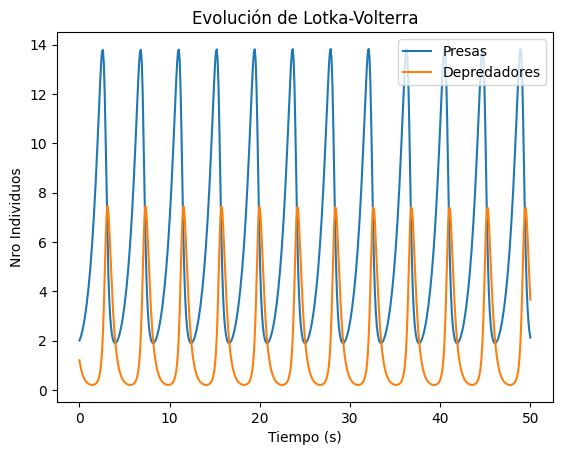

In [173]:
# SIMULACION DE LOTKA-VOLTERRA CON RK4
import numpy as np
import matplotlib.pyplot as plt

alpha = 1.0
beta = 0.5
delta = 0.5
gamma = 3.0

Nt = 500
T = 50.0
time = np.linspace(0, T, Nt)
dt = time[1] - time[0]

x = np.zeros((Nt, 2))
x0 = [2.0, 1.2]
x[0] = x0

params = alpha, beta, delta, gamma
def f(x, params=params):
  x1, x2 = x
  alpha, beta, delta, gamma = params
  dx1dt = alpha * x1 - beta * x1 * x2
  dx2dt = delta * x1 * x2 - gamma * x2
  return np.array([dx1dt, dx2dt])

for k in range(Nt-1):
  x1, x2 = x[k]
  k1 = f(x[k])
  k2 = f(x[k] + 0.5 * dt * k1)
  k3 = f(x[k] + 0.5 * dt * k2)
  k4 = f(x[k] + dt * k3)
  x[k+1] = x[k] + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

plt.plot(time, x[:,0], label="Presas")
plt.plot(time, x[:,1], label="Depredadores")
plt.xlabel("Tiempo (s)")
plt.ylabel("Nro Individuos")
plt.title("Evolución de Lotka-Volterra")
plt.legend(loc="upper right")
plt.show()

In [103]:
from scipy.signal import hilbert

K = 5
N_coeff = 2 * K + 1
N_sim = 1000
params = np.random.uniform(low=[0.8, 0.4, 0.4, 2.5], high=[1.2, 0.6, 0.6, 3.5], size=(N_sim, 4))

def fourier_matrix(phi, K):
    cols = [np.ones_like(phi)]
    for k in range(1, K + 1):
        cols.append(np.cos(k * phi))
        cols.append(np.sin(k * phi))
    return np.column_stack(cols)

hist_sim = []
hist_part = []
for i, config_param in enumerate(params):
  x = np.zeros((Nt, 2))
  x0 = [2.0, 1.2]
  x[0] = x0

  for k in range(Nt-1):
    x1, x2 = x[k]
    k1 = f(x[k], config_param)
    k2 = f(x[k] + 0.5 * dt * k1, config_param)
    k3 = f(x[k] + 0.5 * dt * k2, config_param)
    k4 = f(x[k] + dt * k3, config_param)
    x[k+1] = x[k] + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

  hist_sim.append(x)

  # Tomar cualquiera de las variables y calcular la fase instantanea
  x_centered = x[:, 0] - np.mean(x[:, 0])
  x_analytic = hilbert(x_centered)
  phi_sim = np.mod(np.angle(x_analytic), 2*np.pi)

  # Frecuencia fundamental
  dphi_dt = np.diff(np.unwrap(phi_sim)) / dt
  trim = int(len(dphi_dt) * 0.05)
  w0 = np.mean(dphi_dt[trim:-trim])

  # Proyección a Fourier por mínimos cuadrados
  FM = fourier_matrix(phi_sim, K)
  theta1 = np.linalg.lstsq(FM, x[:, 0], rcond=None)[0]
  theta2 = np.linalg.lstsq(FM, x[:, 1], rcond=None)[0]

  # Guardar todo
  hist_part.append(np.concatenate([[w0], theta1, theta2]))

  if i % 50 == 0:
    print(f"{i} / {N_sim}")

hist_sim = np.array(hist_sim)
hist_part = np.array(hist_part)

0 / 1000
50 / 1000
100 / 1000
150 / 1000
200 / 1000
250 / 1000
300 / 1000
350 / 1000
400 / 1000
450 / 1000
500 / 1000
550 / 1000
600 / 1000
650 / 1000
700 / 1000
750 / 1000
800 / 1000
850 / 1000
900 / 1000
950 / 1000


Text(0.5, 1.0, 'Medición: Nro de Presas + Ruido + Desfase')

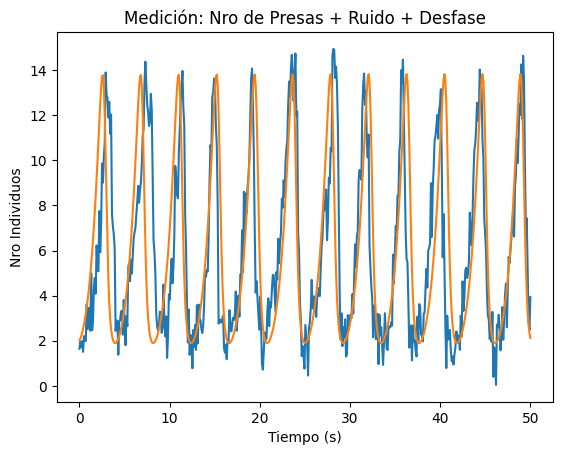

In [221]:
# ADICIONAL: OBSERVACION CON PHASE DRIFT
X_real = np.copy(x)
sigma = 0.25
sigma_phase = 0.25
dtheta = np.cumsum(sigma_phase * np.random.normal(0, np.sqrt(dt), Nt))

dW = np.random.normal(0, np.sqrt(dt), Nt)
time_drifted = np.clip(time + dtheta, time[0], time[-1])
X1_drifted = np.interp(time_drifted, time, X_real[:, 0])
X2_drifted = np.interp(time_drifted, time, X_real[:, 1])
dY = X1_drifted * dt + sigma * dW

plt.plot(time, dY / dt)
plt.plot(time, X_real[:, 0])
plt.xlabel("Tiempo (s)")
plt.ylabel("Nro Individuos")
plt.title("Medición: Nro de Presas + Ruido + Desfase")

In [226]:
N = 5000
indexes = np.random.choice(N_sim, N)
P_phi = np.random.uniform(0.0, 2*np.pi, N)
P = hist_part[indexes]
P += np.random.normal(0, 0.1 * np.std(P, axis=0), P.shape)
w = np.ones(N) / N

sigma_phi = 0.1

history_X1 = np.zeros((Nt, N))
history_X2 = np.zeros((Nt, N))

for k in range(Nt-1):
  # PASO 1: AVANZAR PARTICULAS EN EL MODELO
  P += np.random.normal(0, 0.01 * np.std(P, axis=0), P.shape)
  w0, theta1, theta2 = P[:, 0], P[:, 1:12], P[:, 12:]

  P_phi += w0 * dt + np.random.normal(0, np.sqrt(dt) * sigma_phi, N)
  P_phi = np.mod(P_phi, 2*np.pi)

  FM = fourier_matrix(P_phi, K)
  x1_valpred = np.sum(FM * theta1, axis=1)
  x2_valpred = np.sum(FM * theta2, axis=1)

  # PASO 2: ACTUALIZACION ZAKAI DE LOS PESOS
  inno = dY[k] - x1_valpred * dt
  lkhood = np.exp(- inno**2 / (2 * sigma**2 * dt))
  w *= lkhood
  sum_w = np.sum(w)
  if sum_w > 0:
      w /= sum_w
  else:
      w = np.ones(N) / N

  # PASO 3: GENERACION DE NUEVAS PARTICULAS
  N_eff = 1.0 / np.sum(w**2)
  if N_eff < N / 2:
    indexes = np.random.choice(N, size=N, p=w)
    P = P[indexes]
    P_phi = P_phi[indexes]
    w = np.ones(N) / N

  history_X1[k] = x1_valpred.copy()
  history_X2[k] = x2_valpred.copy()

history_X1[-1] = x1_valpred.copy()
history_X2[-1] = x2_valpred.copy()

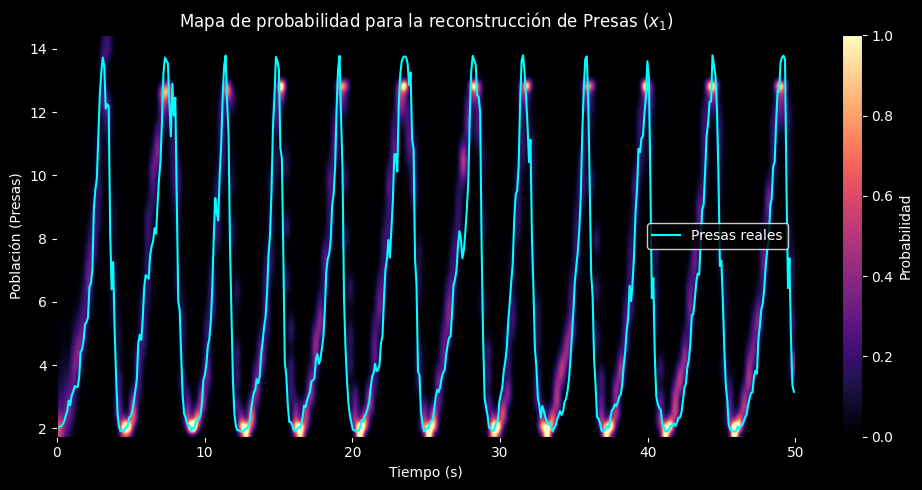

In [227]:
# GRAFICAR MAPA DE PROBABILIDAD PARA PRESAS
plt.figure(figsize=(10, 5))
ax = plt.gca()
ax.set_facecolor('black')
plt.gcf().patch.set_facecolor('black')

timesP = np.repeat(time, N)
x1P = history_X1.flatten()

y_lower = np.percentile(x1P, 0.1)
y_upper = np.percentile(x1P, 99.9)
mask = (x1P >= y_lower) & (x1P <= y_upper)

counts, xedges, yedges = np.histogram2d(timesP[mask], x1P[mask], bins=[150, 60])
probs = counts / N
im = plt.imshow(probs.T, origin='lower',
                extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                aspect='auto', cmap='magma', interpolation='bicubic', vmin=0, vmax=1.0)

plt.plot(time, X1_drifted, color='cyan', label='Presas reales')

ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')

cbar = plt.colorbar(im)
cbar.set_label("Probabilidad", color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax, 'yticklabels'), color='white')

plt.title("Mapa de probabilidad para la reconstrucción de Presas ($x_1)$")
plt.xlabel("Tiempo (s)")
plt.ylabel("Población (Presas)")
plt.legend(facecolor='black', edgecolor='white', labelcolor='white')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1177/2396064800.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(facecolor='black', edgecolor='white', labelcolor='white')


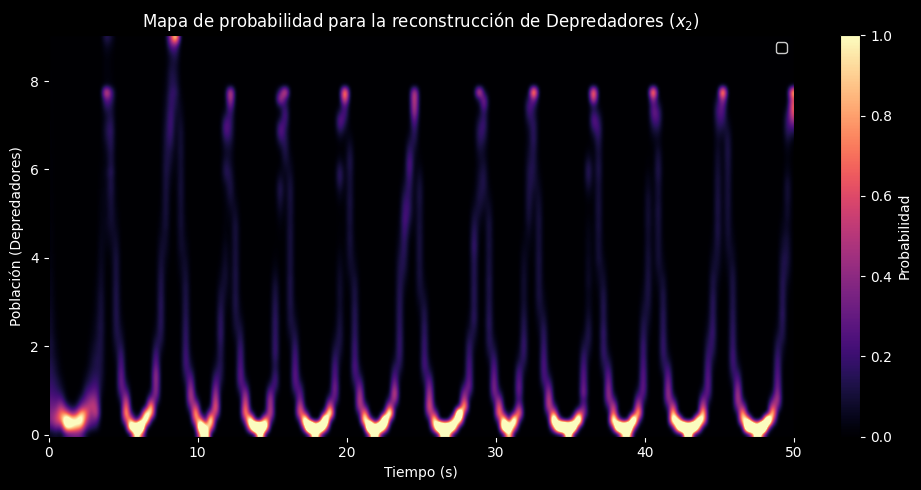

In [229]:
# GRAFICAR MAPA DE PROBABILIDAD PARA DEPREDADORES
plt.figure(figsize=(10, 5))
ax = plt.gca()
ax.set_facecolor('black')
plt.gcf().patch.set_facecolor('black')

timesP = np.repeat(time, N)
x2P = history_X2.flatten()

y_lower = np.percentile(x2P, 0.01)
y_upper = np.percentile(x2P, 99.99)
mask = (x2P >= y_lower) & (x2P <= y_upper)

counts, xedges, yedges = np.histogram2d(timesP[mask], x2P[mask], bins=[150, 60])
probs = counts / N
im = plt.imshow(probs.T, origin='lower',
                extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                aspect='auto', cmap='magma', interpolation='bicubic', vmin=0, vmax=1.0)

#plt.plot(time, X2_drifted, color='cyan', label='Depredadores reales')

ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')

cbar = plt.colorbar(im)
cbar.set_label("Probabilidad", color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax, 'yticklabels'), color='white')

plt.title("Mapa de probabilidad para la reconstrucción de Depredadores ($x_2)$")
plt.xlabel("Tiempo (s)")
plt.ylabel("Población (Depredadores)")
plt.legend(facecolor='black', edgecolor='white', labelcolor='white')
plt.tight_layout()
plt.show()